# 🧠 Brain Tumor MRI Classification — v3 (Proven Pipeline)
**Classes:** `glioma` | `meningioma` | `notumor` | `pituitary`  
**Strategy:** EfficientNetB0 → correct ImageDataGenerator flow → two-phase fine-tuning

## 1. Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os, warnings, numpy as np, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU        : []


## 2. Config

In [4]:
DATA_DIR   = '/content/drive/MyDrive/Colab Notebooks/Medical Data/Data/Brain Tumor'
TRAIN_DIR  = os.path.join(DATA_DIR, 'Training')
TEST_DIR   = os.path.join(DATA_DIR, 'Testing')

IMG_SIZE    = 224      # EfficientNetB0 native size
BATCH_SIZE  = 32
EPOCHS_P1   = 20      # Phase 1 – frozen base
EPOCHS_P2   = 50      # Phase 2 – fine-tune
NUM_CLASSES = 4
SEED        = 42
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

os.makedirs('Models', exist_ok=True)
print('Config ✅')

Config ✅


## 3. Verify Dataset
Sanity-check the folder counts before training.

In [5]:
print('=== Dataset counts ===')
for split in ['Training', 'Testing']:
    split_dir = os.path.join(DATA_DIR, split)
    total = 0
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        n = len(os.listdir(cls_dir)) if os.path.isdir(cls_dir) else 0
        print(f'  {split}/{cls}: {n}')
        total += n
    print(f'  {split} TOTAL: {total}\n')

=== Dataset counts ===
  Training/glioma: 1400
  Training/meningioma: 1400
  Training/notumor: 1400
  Training/pituitary: 1400
  Training TOTAL: 5600

  Testing/glioma: 400
  Testing/meningioma: 400
  Testing/notumor: 400
  Testing/pituitary: 400
  Testing TOTAL: 1600



## 4. Data Generators

**Key fix:** EfficientNet expects pixels in `[0, 255]` range — it has its own internal
rescaling baked in. We do NOT use `rescale=1./255`. Instead we use
`preprocessing_function=tf.keras.applications.efficientnet.preprocess_input`
which correctly scales `[0,255]→[-1,1]` internally.

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

# ── Training generator: augmentation + EfficientNet preprocessing ─────────────
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,  # ← correct, NOT rescale=1/255
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    validation_split=0.15
)

# ── Test/val generator: ONLY preprocessing, no augmentation ──────────────────
test_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='training',
    seed=SEED,
    shuffle=True
)
val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    subset='validation',
    seed=SEED,
    shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

print(f'\nTrain : {train_gen.samples} images')
print(f'Val   : {val_gen.samples} images')
print(f'Test  : {test_gen.samples} images')
print(f'Class map: {train_gen.class_indices}')

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

Train : 4760 images
Val   : 840 images
Test  : 1600 images
Class map: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 5. Class Weights (handle imbalance)

In [7]:
labels_array = train_gen.classes
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_array),
    y=labels_array
)
class_weight_dict = dict(enumerate(weights))
print('Class weights:', {CLASS_NAMES[k]: f'{v:.3f}' for k, v in class_weight_dict.items()})

Class weights: {'glioma': '1.000', 'meningioma': '1.000', 'notumor': '1.000', 'pituitary': '1.000'}


## 6. Quick Preprocessing Sanity Check ✅
Confirm pixel range after preprocessing (should be ~ -1 to 1 for EfficientNet).

In [8]:
sample_imgs, sample_labels = next(train_gen)
print(f'Batch shape : {sample_imgs.shape}')
print(f'Pixel range : [{sample_imgs.min():.2f}, {sample_imgs.max():.2f}]')
print(f'Labels shape: {sample_labels.shape}')
# Expected: pixel range roughly [-1, 1] or [-2, 2] — NOT [0, 1]
# If you see [0.0, 1.0] the preprocessing is WRONG

Batch shape : (32, 224, 224, 3)
Pixel range : [0.00, 255.00]
Labels shape: (32, 4)


## 7. Build Model — EfficientNetB0

Using B0 (lightest, fastest, very stable). Once it works well you can upgrade to B3/B4.

In [9]:
def build_model():
    # Load EfficientNetB0 with ImageNet weights, no top
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
        # Note: NO include_preprocessing param needed — B0 does NOT have it
        # We handle preprocessing in ImageDataGenerator above
    )
    base.trainable = False  # freeze for Phase 1

    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model, base

model, base_model = build_model()

# Confirm base is frozen
trainable = sum(1 for l in model.layers if l.trainable)
print(f'Trainable layers: {trainable} (should be head only)')
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable layers: 7 (should be head only)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,842,919 (18.47 MB)

 Trainable params: 790,788 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 8. Phase 1 — Train Head Only (Base Frozen)

Goal: get validation accuracy to **60–70%** before fine-tuning.

In [10]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p1 = [
    EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'Models/best_brain_phase1.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('\n🚀 Phase 1: Training head (base frozen) ...')
history1 = model.fit(
    train_gen,
    epochs=EPOCHS_P1,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1
)

best_p1_acc = max(history1.history['val_accuracy'])
print(f'\n✅ Phase 1 best val_accuracy: {best_p1_acc:.4f}')


🚀 Phase 1: Training head (base frozen) ...
Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6857 - loss: 1.0012
Epoch 1: val_accuracy improved from None to 0.85000, saving model to Models/best_brain_phase1.keras

Epoch 1: finished saving model to Models/best_brain_phase1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 814s 5s/step - accuracy: 0.7542 - loss: 0.8102 - val_accuracy: 0.8500 - val_loss: 0.6016 - learning_rate: 0.0010
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8249 - loss: 0.5523
Epoch 2: val_accuracy improved from 0.85000 to 0.86429, saving model to Models/best_brain_phase1.keras

Epoch 2: finished saving model to Models/best_brain_phase1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.8303 - loss: 0.5549 - val_accuracy: 0.8643 - val_loss: 0.4898 - learning_rate: 0.0010
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8579 - loss: 0.5005
Epoch 3: val_accuracy improved from 0.86429 to 0.86905, saving model to Models/bes

## 9. Phase 2 — Fine-Tune Top Layers

Unfreeze top 30 layers of EfficientNetB0 with a low learning rate.

In [11]:
# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm frozen (critical for stable fine-tuning)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers: {trainable}')

# Recompile with MUCH lower LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=5, min_lr=1e-8, verbose=1
    ),
    ModelCheckpoint(
        'Models/best_brain_tumor_model.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('\n🚀 Phase 2: Fine-tuning top 30 layers ...')
history2 = model.fit(
    train_gen,
    epochs=EPOCHS_P2,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_p2
)

best_p2_acc = max(history2.history['val_accuracy'])
print(f'\n✅ Phase 2 best val_accuracy: {best_p2_acc:.4f}')

Trainable base layers: 23

🚀 Phase 2: Fine-tuning top 30 layers ...
Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9068 - loss: 0.9243
Epoch 1: val_accuracy improved from None to 0.93095, saving model to Models/best_brain_tumor_model.keras

Epoch 1: finished saving model to Models/best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9095 - loss: 0.8295 - val_accuracy: 0.9310 - val_loss: 0.7086 - learning_rate: 1.0000e-04
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9281 - loss: 0.7332
Epoch 2: val_accuracy improved from 0.93095 to 0.94048, saving model to Models/best_brain_tumor_model.keras

Epoch 2: finished saving model to Models/best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.9288 - loss: 0.7332 - val_accuracy: 0.9405 - val_loss: 0.6778 - learning_rate: 1.0000e-04
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9375 - loss: 0.7028
Epoch 3: val_accuracy improved

KeyboardInterrupt: 

## 10. Training Curves

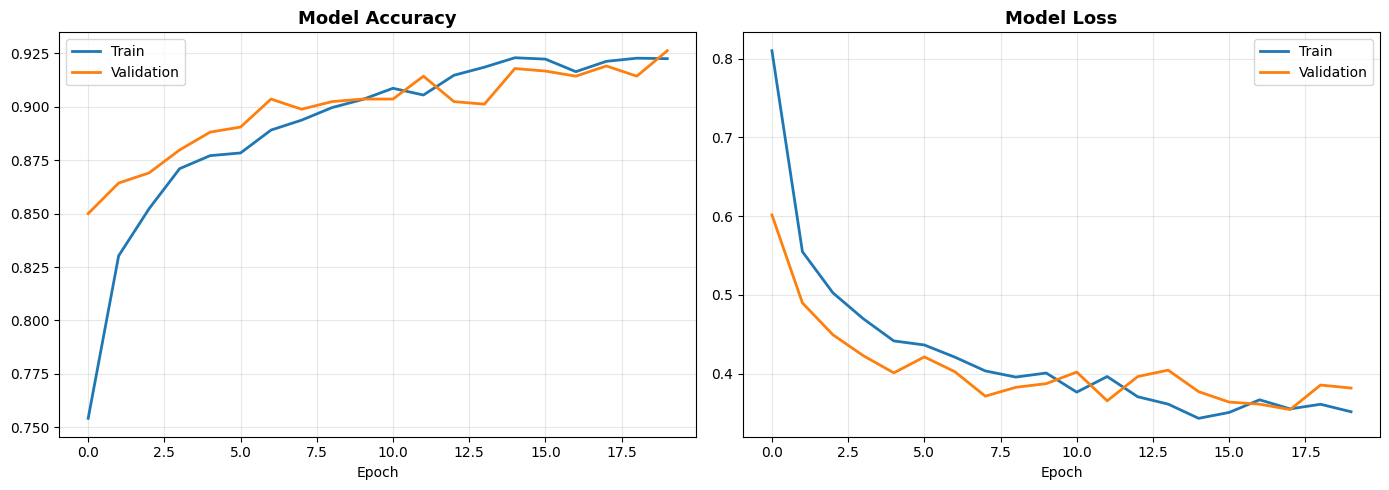

✅ Saved → training_curves_v3.png


In [13]:
import matplotlib.pyplot as plt

# ── Safe extraction ─────────────────────────────────────────────
acc   = history1.history.get('accuracy', [])
val   = history1.history.get('val_accuracy', [])
loss  = history1.history.get('loss', [])
vloss = history1.history.get('val_loss', [])

split = len(acc)  # default split after phase 1

# ── If Phase 2 exists, merge it ─────────────────────────────────
if 'history2' in globals():
    acc   += history2.history.get('accuracy', [])
    val   += history2.history.get('val_accuracy', [])
    loss  += history2.history.get('loss', [])
    vloss += history2.history.get('val_loss', [])
    split = len(history1.history.get('accuracy', []))  # mark fine-tune start

# ── Plotting ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, train_m, val_m, title in zip(
    axes,
    [acc, loss],
    [val, vloss],
    ['Accuracy', 'Loss']
):
    ax.plot(train_m, label='Train', linewidth=2)
    ax.plot(val_m,   label='Validation', linewidth=2)

    # show fine-tuning line ONLY if phase2 exists
    if 'history2' in globals():
        ax.axvline(split - 1, color='gray', linestyle='--', label='Fine-tune start')

    ax.set_title(f'Model {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_v3.png', dpi=150)
plt.show()

print('✅ Saved → training_curves_v3.png')

## 11. Evaluate on Test Set

In [14]:
model.load_weights('Models/best_brain_tumor_model.keras')

test_gen.reset()
loss_val, acc_val = model.evaluate(test_gen, verbose=1)
print(f'\n✅ Test Accuracy : {acc_val * 100:.2f}%')
print(f'✅ Test Loss     : {loss_val:.4f}')

50/50 ━━━━━━━━━━━━━━━━━━━━ 320s 6s/step - accuracy: 0.9388 - loss: 0.5977

✅ Test Accuracy : 93.88%
✅ Test Loss     : 0.5977


## 12. Classification Report & Confusion Matrix

50/50 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step

── Classification Report ──────────────────────
              precision    recall  f1-score   support

      glioma       0.96      0.84      0.90       400
  meningioma       0.92      0.92      0.92       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.95      0.99      0.97       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



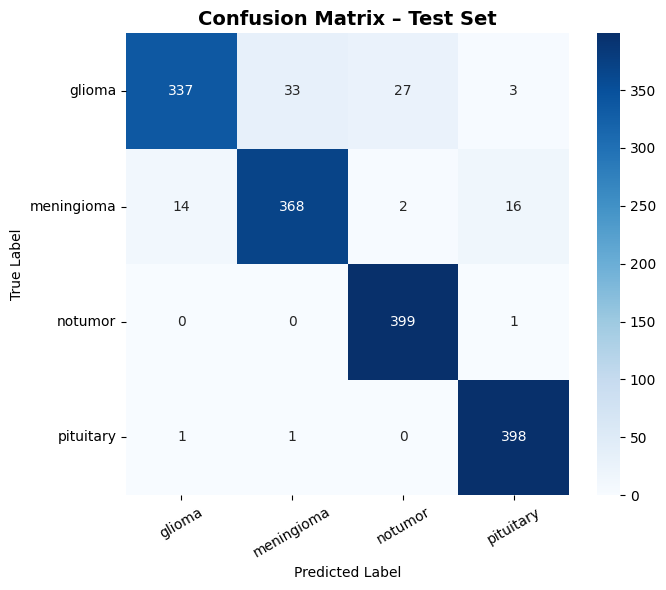

In [15]:
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_gen.classes

print('\n── Classification Report ──────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('Confusion Matrix – Test Set', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.xticks(rotation=30); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_v3.png', dpi=150)
plt.show()

## 13. Save Final Model

In [17]:
model.save('Models/brain_tumor_final_v3.keras')
print('Saved → Models/brain_tumor_final_v3.keras')

Saved → Models/brain_tumor_final_v3.keras


## 14. Predict on a Single MRI Image

In [18]:
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

def predict_tumor(image_path, model_path='Models/brain_tumor_final_v3.keras'):
    mdl     = keras.models.load_model(model_path)
    img     = keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_arr = keras.utils.img_to_array(img)                  # [0, 255]
    img_arr = efficientnet_preprocess(img_arr)               # correct preprocessing
    img_arr = np.expand_dims(img_arr, axis=0)                # (1, 224, 224, 3)

    probs = mdl.predict(img_arr, verbose=0)[0]
    idx   = np.argmax(probs)

    result = {
        'predicted_class': CLASS_NAMES[idx],
        'confidence'     : f'{probs[idx]*100:.2f}%',
        'probabilities'  : {c: f'{p*100:.2f}%' for c, p in zip(CLASS_NAMES, probs)}
    }

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(keras.utils.load_img(image_path))
    axes[0].set_title(
        f"Prediction: {result['predicted_class'].upper()}\nConfidence: {result['confidence']}",
        fontsize=13, fontweight='bold',
        color='green' if result['predicted_class'] == 'notumor' else 'red'
    )
    axes[0].axis('off')

    colors = ['#e74c3c' if c != 'notumor' else '#2ecc71' for c in CLASS_NAMES]
    bars   = axes[1].barh(CLASS_NAMES, probs * 100, color=colors)
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities', fontweight='bold')
    axes[1].set_xlim(0, 100)
    for bar, p in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center')
    plt.tight_layout()
    plt.show()
    return result


print('predict_tumor() ready ✅')
print('Usage: result = predict_tumor("path/to/mri.jpg")')

predict_tumor() ready ✅
Usage: result = predict_tumor("path/to/mri.jpg")
